# 📷 Stage 1 · Digital Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vshabanova/bachelor/blob/main/01_image-processing/digital-data.ipynb)

**Topic of the week:** Introduction to Image Processing · **Lecture:** Tue 22.09 · **Startup question:** *Can we turn whatever the camera gives us into one consistent format?*

A camera frame is just a grid of numbers. Before any clever computer vision, the startup needs every frame in the same size, orientation and colour space, and a test set that is locked away on day one.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`digital-data_prepare/action.yaml`](digital-data_prepare/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Digital-Data.md`](Todo_Digital-Data.md) |
| Code | `stages/s1_digital_data.py` |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "vshabanova/bachelor"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

✔ Stages up to 'digital_data' ran with your tinker-zone values
file: data/synthetic/drop/drop_0000.jpg
shape: (256, 256, 3)   dtype: uint8   min/max: 4 255


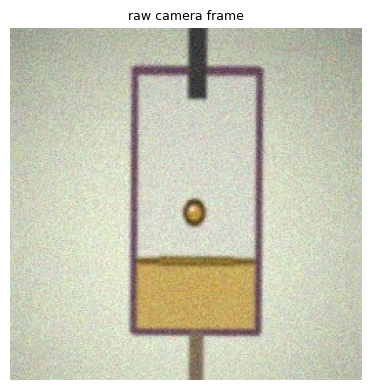

In [2]:
cfg = prepare("digital_data")
s1 = load_images("digital_data")
row = next(r for r in s1.rows if r["label"] == "drop")
raw = cv2.imread(row["source"])  # OpenCV loads colour as B, G, R — not R, G, B!
print("file:", row["source"])
print("shape:", raw.shape, "  dtype:", raw.dtype, "  min/max:", raw.min(), raw.max())
show([raw], ["raw camera frame"], color_space="bgr", size=4)

## Pixels are numbers
The frame is a NumPy array of shape *height × width × channels*. Here is a 6×6 patch of the blue channel from the middle of the frame:

In [3]:
y, x = raw.shape[0] // 2, raw.shape[1] // 2
print(raw[y - 3:y + 3, x - 3:x + 3, 0])

[[202 205 202 164 125  90]
 [196 183 185 144 111  70]
 [201 205 163 115  66  39]
 [203 178 141  89  45  48]
 [187 171 110  84  61  55]
 [179 126  92  70  61  96]]


## Channels and colour spaces
The same frame, split into channels in three colour spaces. Look for the channel where the amber fluid is most different from the air above it.

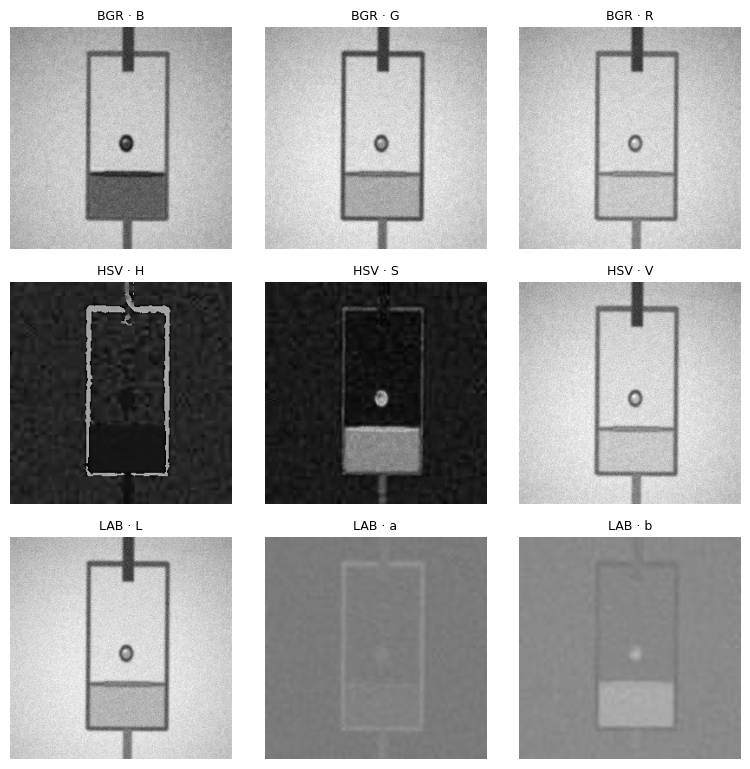

In [4]:
spaces = {"BGR": (raw, "BGR"), "HSV": (cv2.cvtColor(raw, cv2.COLOR_BGR2HSV), "HSV"),
          "LAB": (cv2.cvtColor(raw, cv2.COLOR_BGR2LAB), "Lab")}
imgs, titles = [], []
for name, (im, chans) in spaces.items():
    for i, c in enumerate(chans):
        imgs.append(im[..., i]); titles.append(f"{name} · {c}")
show(imgs, titles, cols=3, size=2.6)

## Resizing: which pixels survive?
Shrinking to 32×32 throws away 98% of the pixels. The interpolation method decides how the rest are averaged.

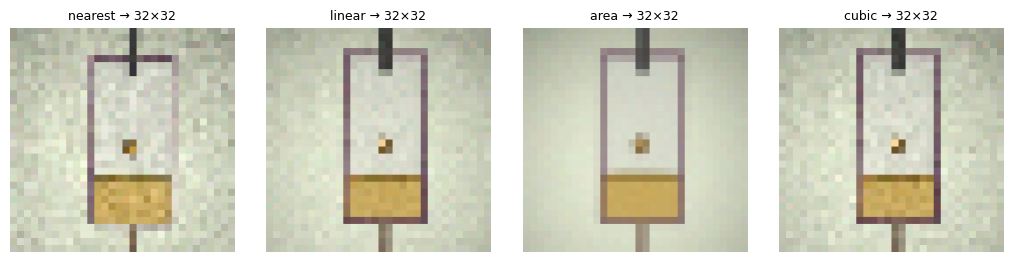

In [5]:
from stages.s1_digital_data import INTERPOLATION
small = {k: cv2.resize(raw, (32, 32), interpolation=v) for k, v in INTERPOLATION.items()}
show([cv2.resize(s, (256, 256), interpolation=cv2.INTER_NEAREST) for s in small.values()],
     [f"{k} → 32×32" for k in small], color_space="bgr")

## The stage itself: `prepare()`
This is exactly the function CI runs on every frame, here with a few variations of your config. Note what the crop does to the aspect ratio.

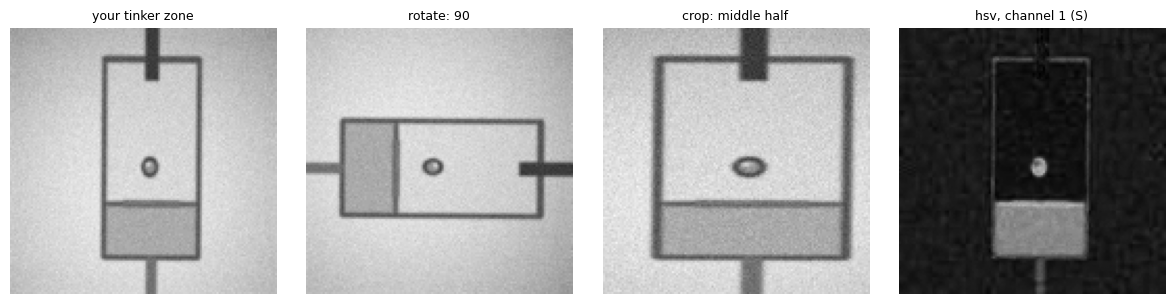

In [6]:
from stages.s1_digital_data import prepare as prepare_frame
d = cfg["digital_data"]
variants = {"your tinker zone": d, "rotate: 90": {**d, "rotate": 90},
            "crop: middle half": {**d, "crop": [0.25, 0, 0.75, 1]},
            "hsv, channel 1 (S)": {**d, "color_space": "hsv", "channel": 1}}
show([prepare_frame(raw, v) for v in variants.values()], list(variants), size=3)

## 🧪 Your turn
1. Which single channel would you pick to separate fluid from air? Set `color_space` and `channel` in the tinker zone and predict what happens to segmentation in stage 4.
2. Try `size: [32, 32]`. Stage 6 must still find a drop that is now about one pixel wide. Does it?
3. The crop above squashed the chamber. Why might that *not* matter for a classifier, and when would it?

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.